### Introduction

### Contexte :
CalCOFI collecte des données depuis 1949 au larfe de la Californie pour étudier les cyvles climatiques. Ceratins phénomènes comme El Niño et l'impact du réchauffement climatique sur les écosystèmes marins, sont étudiés grâce à ces données.

### Objectif :
Dans ce projet, nous étudions ces **données océanographiques** issues du programme CalCOFI afin d'explorer les relations entre **la température** de l'océan et d'autres variables mesurées telles que la profondeur et la salinité. Ici, l'objectif est de concevoir et de mettre en oeuvre un modèle prédictif, à l'aide de méthodes d'apprentissage automatique.

### Structure du projet :
1. __Découverte des données__ : Chargement des données afin d'explorer les variables disponibles.
2. __Nettoyage, exploration et visualisation des données__ : Filtrage du jeu de données, et visualiser les données pour juger nos hypothèses.
3. __Feature engineering__ : Enrichissement du dataset pour tester les modèles et améliorer les prédictions.
4. __Modélisation__ : Construction d'un modèle de classification.
5. __Evaluation__ : Comparaison des modèles pour évaluer les performances.
6. __Interprétation et Conclusion__

## Découverte des données

Dans cette partie, nous chargeons les données et réalisons une première familiarisation afin de comprendre la structure du fichier et identifier les éléments pertinents pour le dataset.

In [7]:
# Importation des bibliothèques essentielles
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("bottle.csv")

C:\Users\mokht\AppData\Local\Temp\ipykernel_14832\80261782.py:7: DtypeWarning: Columns (47,73) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("bottle.csv")


In [9]:
# Aperçu des premières lignes
df.head()

,Cst_Cnt,Btl_Cnt,Sta_ID,Depth_ID,Depthm,T_degC,Salnty,O2ml_L,STheta,O2Sat,...,R_PHAEO,R_PRES,R_SAMP,DIC1,DIC2,TA1,TA2,pH2,pH1,DIC Quality Comment
0,1,1,054.0 056.0,19-4903CR-HY-060-0930-05400560-0000A-3,0,10.50,33.440,NaN,25.649,NaN,...,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2,054.0 056.0,19-4903CR-HY-060-0930-05400560-0008A-3,8,10.46,33.440,NaN,25.656,NaN,...,NaN,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,3,054.0 056.0,19-4903CR-HY-060-0930-05400560-0010A-7,10,10.46,33.437,NaN,25.654,NaN,...,NaN,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,4,054.0 056.0,19-4903CR-HY-060-0930-05400560-0019A-3,19,10.45,33.420,NaN,25.643,NaN,...,NaN,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,5,054.0 056.0,19-4903CR-HY-060-0930-05400560-0020A-7,20,10.45,33.421,NaN,25.643,NaN,...,NaN,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


On remmarque qu'il existe plusieurs colonnes contenant la valeur NaN (aucune donnée), Les colonnes utiles sont donc : T_DegC (température), Salnty (Salinité), Depthm (Profondeur).

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 864863 entries, 0 to 864862
Data columns (total 74 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Cst_Cnt              864863 non-null  int64  
 1   Btl_Cnt              864863 non-null  int64  
 2   Sta_ID               864863 non-null  object 
 3   Depth_ID             864863 non-null  object 
 4   Depthm               864863 non-null  int64  
 5   T_degC               853900 non-null  float64
 6   Salnty               817509 non-null  float64
 7   O2ml_L               696201 non-null  float64
 8   STheta               812174 non-null  float64
 9   O2Sat                661274 non-null  float64
 10  Oxy_µmol/Kg          661268 non-null  float64
 11  BtlNum               118667 non-null  float64
 12  RecInd               864863 non-null  int64  
 13  T_prec               853900 non-null  float64
 14  T_qual               23127 non-null   float64
 15  S_prec           

Certaines colonnes (notamment T_degC, Salnty, Depthm) sont des floats. D'autres colonnes sont moins utiles pour la modélisation (comme Sta_ID...).

In [15]:
# Statistiques descirptives
df.describe()

,Cst_Cnt,Btl_Cnt,Depthm,T_degC,Salnty,O2ml_L,STheta,O2Sat,Oxy_µmol/Kg,BtlNum,...,R_CHLA,R_PHAEO,R_PRES,R_SAMP,DIC1,DIC2,TA1,TA2,pH2,pH1
count,864863.000000,864863.000000,864863.000000,853900.000000,817509.000000,696201.000000,812174.000000,661274.000000,661268.000000,118667.000000,...,225276.000000,225275.000000,864863.000000,122006.000000,1999.000000,224.000000,2084.000000,234.000000,10.000000,84.000000
mean,17138.790958,432432.000000,226.831951,10.799677,33.840350,3.392468,25.819394,57.103779,148.808694,10.497426,...,0.450225,0.198599,228.395694,162.071521,2153.239714,2168.148330,2256.055845,2278.858803,7.948570,7.910983
std,10240.949817,249664.587267,316.050259,4.243825,0.461843,2.073256,1.167787,37.094137,90.187533,6.189688,...,1.208566,0.376539,319.456731,85.722796,112.995202,154.852332,34.844435,58.496495,0.021216,0.077666
min,1.000000,1.000000,0.000000,1.440000,28.431000,-0.010000,20.934000,-0.100000,-0.434900,0.000000,...,-0.010000,-3.890000,0.000000,0.000000,1948.850000,1969.440000,2181.570000,2198.150000,7.923100,7.618300
25%,8269.000000,216216.500000,46.000000,7.680000,33.488000,1.360000,24.965000,21.100000,60.915470,5.000000,...,0.050000,0.050000,46.000000,200.000000,2028.330000,2008.977500,2230.322500,2229.062500,7.931475,7.898675
50%,16848.000000,432432.000000,125.000000,10.060000,33.863000,3.440000,25.996000,54.400000,151.064150,10.000000,...,0.160000,0.110000,126.000000,206.000000,2170.640000,2265.885000,2244.325000,2247.505000,7.946650,7.928850
75%,26557.000000,648647.500000,300.000000,13.880000,34.196900,5.500000,26.646000,97.600000,240.379600,16.000000,...,0.390000,0.230000,302.000000,214.000000,2253.810000,2315.525000,2278.505000,2316.452500,7.963300,7.955100
max,34404.000000,864863.000000,5351.000000,31.140000,37.034000,11.130000,250.784000,214.100000,485.701800,25.000000,...,66.110000,65.300000,5458.000000,424.000000,2367.800000,2364.420000,2434.900000,2437.000000,7.988300,8.047700


- Pour la __profondeur__, une variabilité normale avec une moyenne de 227m, mais la présence de valeurs aberrantes (max : 5351m) nous permet de supprimer certaines données.
- La __température__ varie entre 1.4°C et 31.1°C, données cohérentes.
- La __Salinité__ reste généralement stable autour de 33.8 PSU.

Maintenant on va afficher les colonnes avec le plus de valeurs nulles pour savoir quoi filtrer ensuite.

In [19]:
# Pourcentage de valeurs manquantes par colonne
missing = df.isnull().mean().sort_values(ascending=False)
missing[missing > 0].head(10)

pH2                    0.999988
DIC Quality Comment    0.999936
pH1                    0.999903
DIC2                   0.999741
TA2                    0.999729
DIC1                   0.997689
TA1                    0.997590
C14A2p                 0.985267
C14A1p                 0.985246
C14As2                 0.983334
dtype: float64

Ces colonnes doivent être ignorées car elles sont inutilisables.

Et enfin on va visualiser la distribution des variables clés.

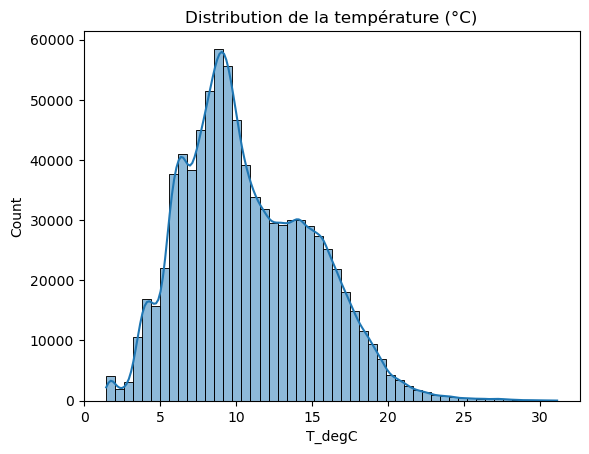

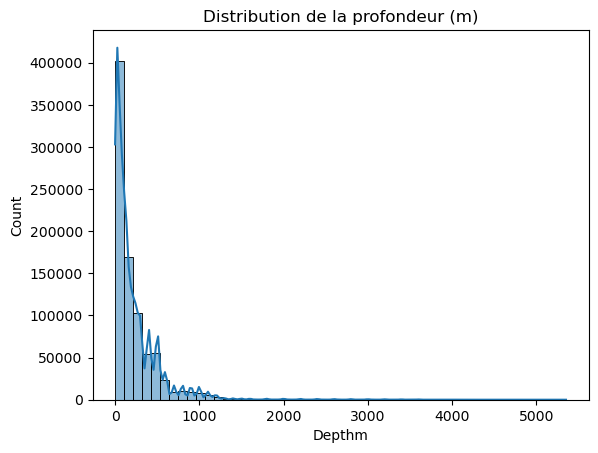

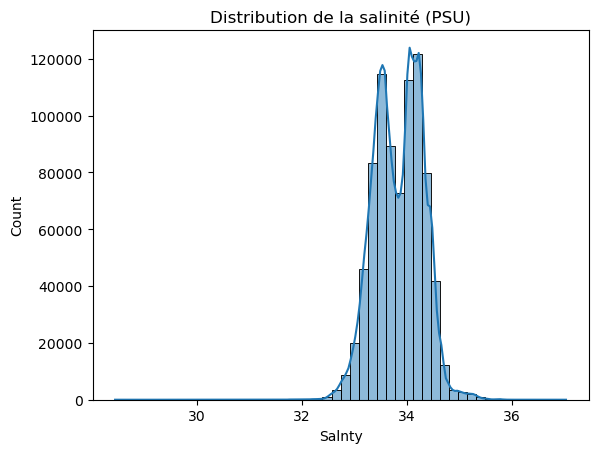

In [23]:
# Distribution de la température
sns.histplot(df['T_degC'], bins=50, kde=True)
plt.title("Distribution de la température (°C)")
plt.show()

# Distribution de la profondeur
sns.histplot(df['Depthm'], bins=50, kde=True)
plt.title("Distribution de la profondeur (m)")
plt.show()

# Distribution de la salinité
sns.histplot(df['Salnty'], bins=50, kde=True)
plt.title("Distribution de la salinité (PSU)")
plt.show()

Distribution de la **température** :
- majoritairement comprise entre **5°C** et **15°C**, typique au large de la Californie.
- quelques mesures autour de **20°C** et **30°C**, ce qui peut correspondre à des mesures en été.
- Aucune température négative (pas d'erreur).

Distribution de la **profondeur** :
- Une forte concentration des mesures entre **0** et **300m**.
- Quelques valeurs extrêmes allant jusqu'à plus de **5000m**, cela peut refléter des erreurs qu'on devra filtrer.

Distribution de la **salinité** :
- Une forte concentration autour de **33** et **35 PSU**.
- Une double bosse qui peut correspondre à deux zones océanographiques différentes

## Nettoyage, exploration et visualisation des données

Selon l'exploration réalisée précédemment, nous allons nettoyer le jeu pour éviter les biais, puis les explorer visuellement afin de modéliser la température océanique

On commence par nettoyer le dataset

In [29]:
# Copie du dataset
df_clean = df.copy()

# Garder uniquement les variables utiles
df_clean = df_clean[['T_degC', 'Salnty', 'Depthm']]

# Supprimer les valeurs manquantes
df_clean = df_clean.dropna()

# Supprimer les profondeurs supérieures à 500 m
df_clean = df_clean[df_clean['Depthm'] <= 500]

# Supprimer les salinités anormalement basses (< 30 PSU)
df_clean = df_clean[df_clean['Salnty'] >= 30]

# Résultat
print(f"Nombre de lignes avant nettoyage : {df.shape[0]}")
print(f"Nombre de lignes après nettoyage : {df_clean.shape[0]}")
df_clean.describe()

Nombre de lignes avant nettoyage : 864863
Nombre de lignes après nettoyage : 733502


,T_degC,Salnty,Depthm
count,733502.000000,733502.000000,733502.000000
mean,11.535753,33.779065,148.398163
std,3.877890,0.441942,137.540284
min,3.490000,30.110000,0.000000
25%,8.500000,33.459000,34.000000
50%,10.710000,33.770000,100.000000
75%,14.334000,34.110000,230.000000
max,31.140000,37.034000,500.000000


Le dataset a maintenant une forme plus propre et cohérente, avec un nombre de mesure largement suffisant pour la modélisation. On veut donc visualiser la distribution après nettoyage.

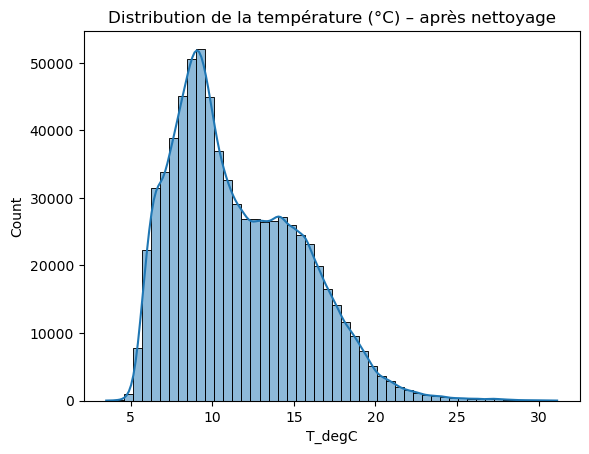

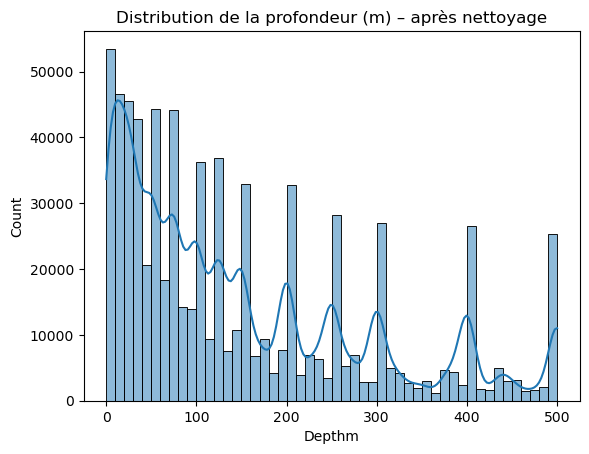

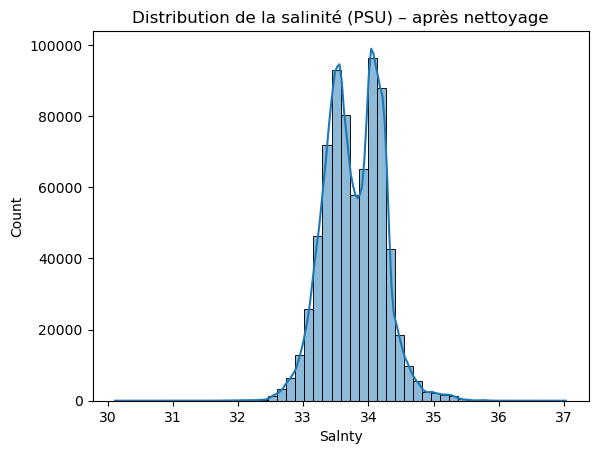

In [33]:
# Température
sns.histplot(df_clean['T_degC'], bins=50, kde=True)
plt.title("Distribution de la température (°C) – après nettoyage")
plt.show()

# Profondeur
sns.histplot(df_clean['Depthm'], bins=50, kde=True)
plt.title("Distribution de la profondeur (m) – après nettoyage")
plt.show()

# Salinité
sns.histplot(df_clean['Salnty'], bins=50, kde=True)
plt.title("Distribution de la salinité (PSU) – après nettoyage")
plt.show()

**Température** : toujours stable, avec un pic autour de **9-10°C**, distribution cohérente.

**Profondeur** : On découvre le protocole de prélèvement de CalCOFI, des pics nets à des intervalles réguliers (tous les 10m jusqu'à 100m, puis tous les 25m ou 50 au-delà), beaucoup de mesures sont en surface.

**Salinité** : toujours une double bosse avec une forte concentration entre **33.5** et **35 PSU**.

Matrice de corrélation :

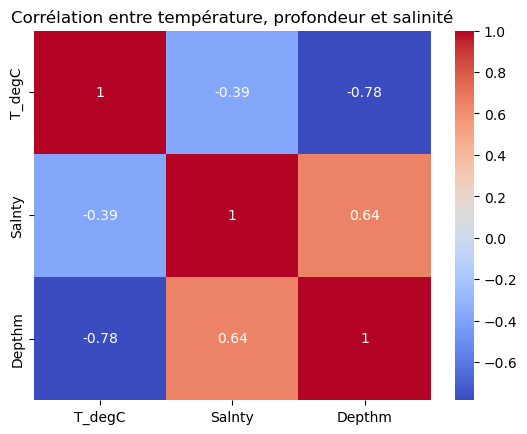

In [36]:
corr = df_clean.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Corrélation entre température, profondeur et salinité")
plt.show()

On remarque une forte corrélation négative entre la température et la profondeur : plus on descend, plus l'eau est froide. De plus, on a une faible corrélation entre la salinité et la température, mais à suvreiller.

Maintenant exprimons la température en fonction de la profondeur, et de la salinité.

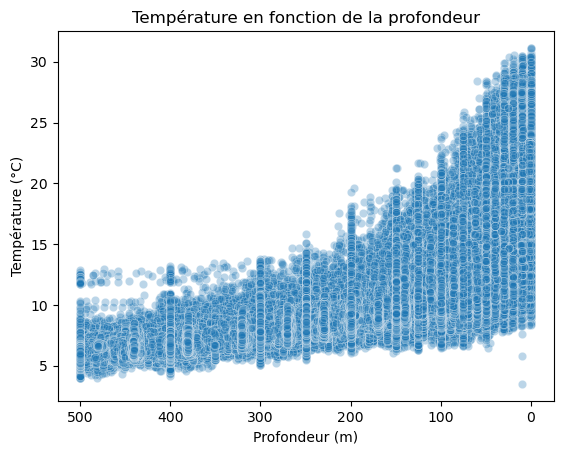

In [39]:
# Température vs profondeur
sns.scatterplot(data=df_clean, x='Depthm', y='T_degC', alpha=0.3)
plt.gca().invert_xaxis()
plt.title("Température en fonction de la profondeur")
plt.xlabel("Profondeur (m)")
plt.ylabel("Température (°C)")
plt.show()

Il y'a une **forte relation inverse** entre la profondeur et la température, cela confirme notre **hypothèse** initiale : plus la profondeur **augmente**, plus la température **diminue**.

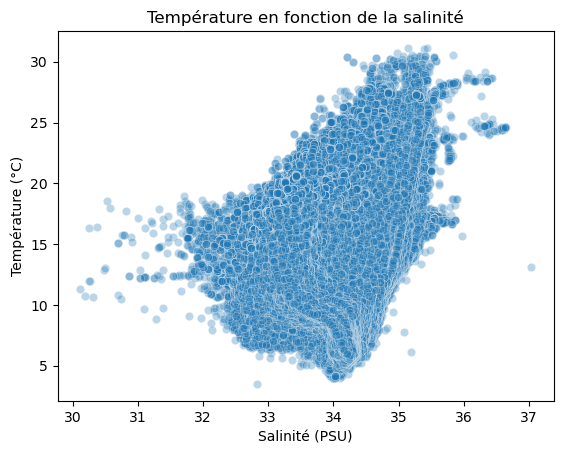

In [43]:
sns.scatterplot(data=df_clean, x='Salnty', y='T_degC', alpha=0.3)
plt.title("Température en fonction de la salinité")
plt.xlabel("Salinité (PSU)")
plt.ylabel("Température (°C)")
plt.show()

En revanche, la salinité montre peu de corrélation directe, pas de tendance linéaire claire. Cela pourrait indiquer que la salinité n'explique pas **directement** la température, mais peut agir en **interaction** avec la profondeur. Pour cela, on devra exprimer une relation **non-linéaire** (salinité + profondeur) qui pourrait améliorer la prédiction.

## Feature engineering

Pour améliorer la performance des modèles, nous allons créer dans cette partie de nouvelles **features** à partir des variables existantes, afin d'exprimer les relations **complexes* entre la température et les autres variables

In [48]:
# Copie
df_feat = df_clean.copy()

Profondeur au carré : Afin qu'un modèle lineaire apprenne une courbe pour représenter la baisse rapide de température + stabilisation

In [52]:
# Ajout d’un terme quadratique
df_feat['Depthm_squared'] = df_feat['Depthm'] ** 2

Les couches de l'océan ne se comportent pas pareil

In [55]:
# Création de zones océanographiques
df_feat['Depth_zone'] = pd.cut(
    df_feat['Depthm'],
    bins=[-1, 50, 200, 500],
    labels=['surface', 'thermocline', 'profondeur']
)


L'interaction entre variables permet au modèle de capter les effets combinés qui se sont visibles séparément.

In [58]:
# Terme d'interaction
df_feat['Depth_Salinity'] = df_feat['Depthm'] * df_feat['Salnty']


Nous allons visualiser cela
-  Ligne au milieu = valeur centrale (médiane)
- boîte = valeurs typiques
- traits = plage normale
- cercles = valeurs extrêmes

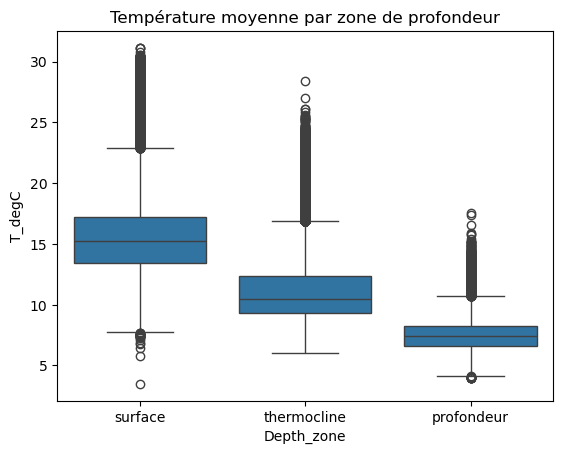

In [61]:
sns.boxplot(x='Depth_zone', y='T_degC', data=df_feat)
plt.title("Température moyenne par zone de profondeur")
plt.show()

- En surface (0-50m) : Température élevée et variable autour de 15°C, influence direct des conditions météorologiques
- Dans la thermocline (50-200m) : Chute brutale de température, médiane autour de 11°C, c'est une zone de transition thermique (l'eau se refroiditi rapidement)
- En profondeur (> 200m) : Température faible et stable autour de 7°C, environnement plus homogène isolé des effets de surface

Vérification des corrélations des nouvelles features

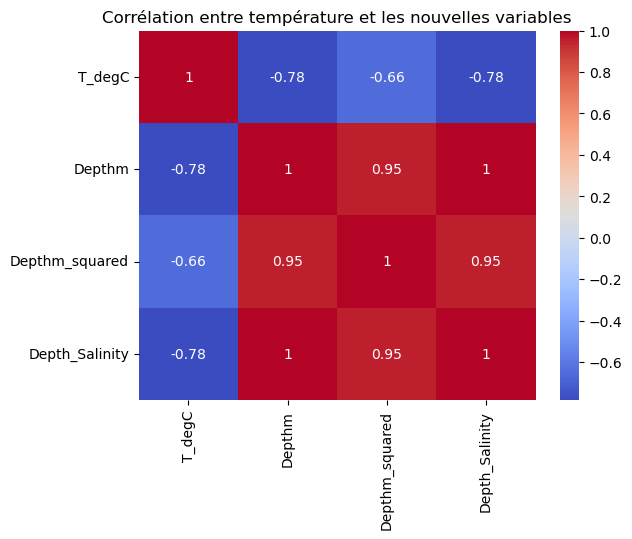

In [65]:
corr_f = df_feat[['T_degC', 'Depthm', 'Depthm_squared', 'Depth_Salinity']].corr()
sns.heatmap(corr_f, annot=True, cmap='coolwarm')
plt.title("Corrélation entre température et les nouvelles variables")
plt.show()

## Modélisation 


Régression Linéaire simple

En utilisant la température comme variable cible et plusieurs variables explicatives : la salinité, la profondeur, son carré, et le terme d’interaction profondeur × salinité. On va entraîner les trois modèles (régression polynomiale, arbre de décision, forêt aléatoire) avec ces variables, comparer les performances.

In [94]:
from sklearn.model_selection import train_test_split

# Définir les features utilisées dans le modèle
features = ['Salnty', 'Depthm', 'Depthm_squared', 'Depth_Salinity']

# On prend un échantillon ou le dataset complet selon ce que tu veux tester
X = df_feat[features]
y = df_feat['T_degC']

# Séparer en entraînement et test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [96]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

lin_model = LinearRegression()
lin_model.fit(X_train, y_train)
y_pred = lin_model.predict(X_test)

print("Régression Linéaire")
print("R2 Score :", r2_score(y_test, y_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred)))

Régression Linéaire
R2 Score : 0.7516575885923988
RMSE : 1.9372700006688832


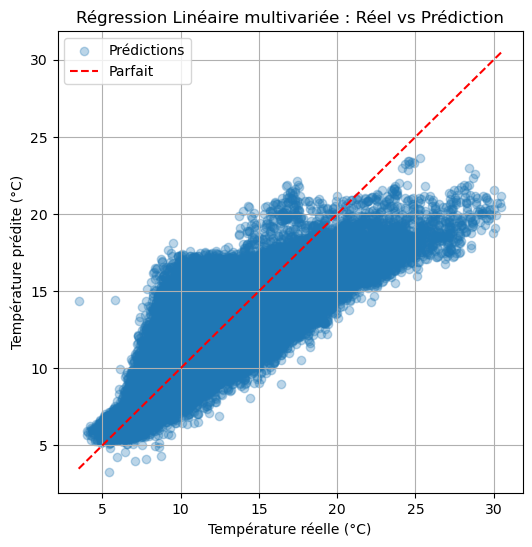

In [100]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.3, label="Prédictions")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label="Parfait")
plt.xlabel("Température réelle (°C)")
plt.ylabel("Température prédite (°C)")
plt.title("Régression Linéaire multivariée : Réel vs Prédiction")
plt.legend()
plt.grid()
plt.show()

C:\Users\mokht\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


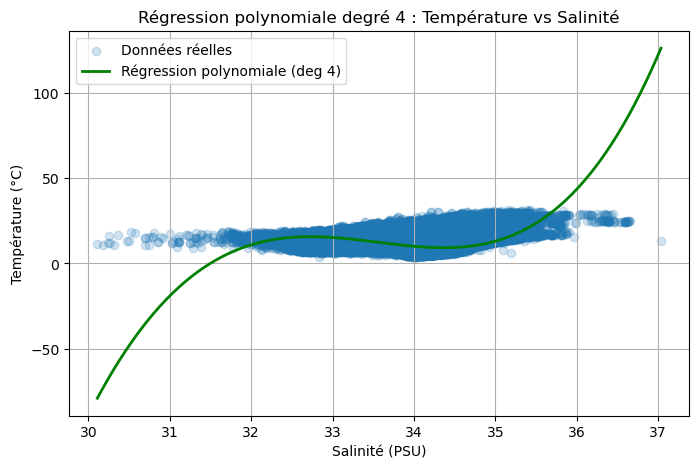

In [115]:
# Création d’une plage continue de valeurs de salinité pour tracer une courbe lisse
x_range = np.linspace(X_sal['Salnty'].min(), X_sal['Salnty'].max(), 300).reshape(-1, 1)
y_range = poly_model.predict(x_range)

# Affichage
plt.figure(figsize=(8,5))
plt.scatter(X_sal, y_sal, alpha=0.2, label="Données réelles")
plt.plot(x_range, y_range, color='g', linewidth=2, label="Régression polynomiale (deg 4)")
plt.xlabel("Salinité (PSU)")
plt.ylabel("Température (°C)")
plt.title("Régression polynomiale degré 4 : Température vs Salinité")
plt.legend()
plt.grid()
plt.show()

In [118]:
from sklearn.tree import DecisionTreeRegressor
import numpy as np
import matplotlib.pyplot as plt

# Données
X_sal = df_feat[['Salnty']]
y_sal = df_feat['T_degC']

# Entraînement
tree_model = DecisionTreeRegressor(max_depth=5, random_state=42)  # limite la complexité pour une courbe lisible
tree_model.fit(X_sal, y_sal)

DecisionTreeRegressor(max_depth=5, random_state=42)

C:\Users\mokht\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


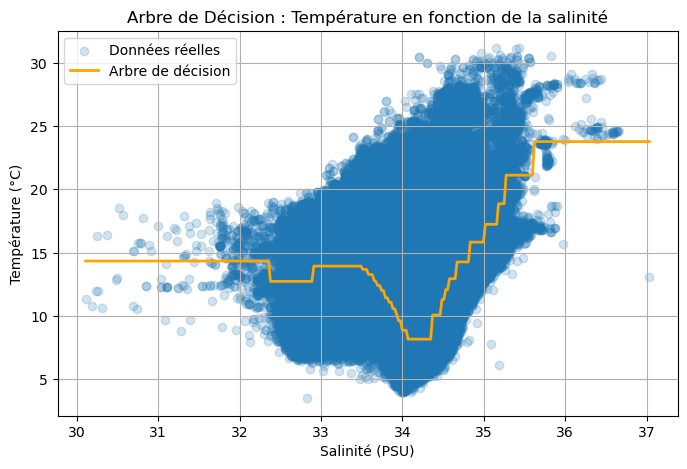

In [120]:
# Plage continue de salinité pour prédiction
x_range = np.linspace(X_sal['Salnty'].min(), X_sal['Salnty'].max(), 300).reshape(-1, 1)
y_tree_range = tree_model.predict(x_range)

# Affichage
plt.figure(figsize=(8,5))
plt.scatter(X_sal, y_sal, alpha=0.2, label="Données réelles")
plt.plot(x_range, y_tree_range, color='orange', linewidth=2, label="Arbre de décision")
plt.xlabel("Salinité (PSU)")
plt.ylabel("Température (°C)")
plt.title("Arbre de Décision : Température en fonction de la salinité")
plt.legend()
plt.grid()
plt.show()

Ici, j'entraîne un arbre de décision sur toutes les variables explicatives.
L’arbre explore les interactions entre variables et s’adapte automatiquement à leur non-linéarité.
La profondeur de l’arbre est limitée à 6 pour éviter le sur-apprentissage.

In [125]:
from sklearn.ensemble import RandomForestRegressor

# Données uniquement sur la salinité
X_sal = df_feat[['Salnty']]
y_sal = df_feat['T_degC']

# Entraînement du modèle
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_sal, y_sal)

RandomForestRegressor(n_jobs=-1, random_state=42)

C:\Users\mokht\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


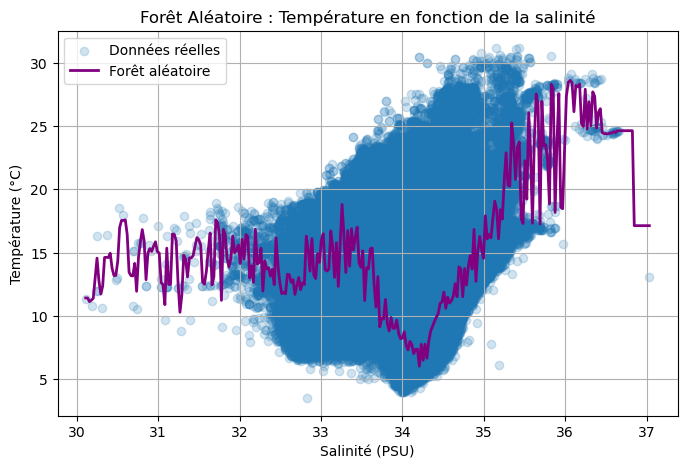

In [127]:
# Création d’un intervalle de salinité pour prédiction lissée
x_range = np.linspace(X_sal['Salnty'].min(), X_sal['Salnty'].max(), 300).reshape(-1, 1)
y_rf_range = rf_model.predict(x_range)

# Affichage
plt.figure(figsize=(8,5))
plt.scatter(X_sal, y_sal, alpha=0.2, label="Données réelles")
plt.plot(x_range, y_rf_range, color='purple', linewidth=2, label="Forêt aléatoire")
plt.xlabel("Salinité (PSU)")
plt.ylabel("Température (°C)")
plt.title("Forêt Aléatoire : Température en fonction de la salinité")
plt.legend()
plt.grid()
plt.show()

La forêt aléatoire est un ensemble de plusieurs arbres de décision (ici 100), chacun entraîné sur un sous-échantillon différent.
Elle produit une prédiction plus lisse et robuste que l’arbre seul.
On voit ici une tendance continue et plus fluide dans la variation de la température en fonction de la salinité.

On sélectionne ici plusieurs variables explicatives pour mieux prédire la température :
-la salinité
-la profondeur
-la profondeur au carré (pour capter une relation non-linéaire)
-un terme d’interaction (profondeur × salinité)
On divise ensuite les données en un jeu d'entraînement (80%) et un jeu de test (20%).

In [131]:
# Sélection des variables explicatives
X_multi = df_feat[['Salnty', 'Depthm', 'Depthm_squared', 'Depth_Salinity']]
y_multi = df_feat['T_degC']

# Séparation en jeu d'entraînement et de test
from sklearn.model_selection import train_test_split

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)


Ici, on utilise une régression polynomiale multivariée de degré 2.
Cela permet de capter des interactions complexes entre les variables, comme une variation non linéaire de la température avec la profondeur.
On évalue ensuite le modèle avec l’erreur quadratique moyenne (MSE) et le R².

In [134]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Transformation polynomiale de degré 2 sur toutes les variables
poly_multi = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly_multi.fit_transform(X_train_m)
X_test_poly = poly_multi.transform(X_test_m)

# Modèle de régression linéaire
poly_lin_model = LinearRegression()
poly_lin_model.fit(X_train_poly, y_train_m)

# Prédictions
y_pred_poly = poly_lin_model.predict(X_test_poly)

# Évaluation
mse_poly = mean_squared_error(y_test_m, y_pred_poly)
r2_poly = r2_score(y_test_m, y_pred_poly)

print(f"Régression polynomiale (multi) — MSE : {mse_poly:.3f}, R² : {r2_poly:.3f}")


Régression polynomiale (multi) — MSE : 3.437, R² : 0.773


Ici, j'entraîne un arbre de décision sur toutes les variables explicatives.
L’arbre explore les interactions entre variables et s’adapte automatiquement à leur non-linéarité.
La profondeur de l’arbre est limitée à 6 pour éviter le sur-apprentissage.

In [145]:
tree_model_m = DecisionTreeRegressor(max_depth=6, random_state=42)
tree_model_m.fit(X_train_m, y_train_m)

y_pred_tree = tree_model_m.predict(X_test_m)

mse_tree = mean_squared_error(y_test_m, y_pred_tree)
r2_tree = r2_score(y_test_m, y_pred_tree)

print(f"Arbre de décision — MSE : {mse_tree:.3f}, R² : {r2_tree:.3f}")


Arbre de décision — MSE : 3.084, R² : 0.796


La forêt aléatoire utilise plusieurs arbres pour produire une prédiction plus stable et moins sensible au bruit.
C’est un excellent modèle pour capturer des relations complexes dans des données multivariées.
On observe généralement une amélioration du R² et une réduction de l’erreur.

In [148]:
rf_model_m = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_model_m.fit(X_train_m, y_train_m)

y_pred_rf = rf_model_m.predict(X_test_m)

mse_rf = mean_squared_error(y_test_m, y_pred_rf)
r2_rf = r2_score(y_test_m, y_pred_rf)

print(f"Forêt aléatoire — MSE : {mse_rf:.3f}, R² : {r2_rf:.3f}")


Forêt aléatoire — MSE : 2.951, R² : 0.805


Ce tableau permet de comparer les performances des trois approches.
Le modèle avec la meilleure valeur de R² (proche de 1) et la plus petite erreur MSE est le plus performant.
En général, la forêt aléatoire donne les meilleurs résultats sur ce type de problème.

In [151]:
# Comparaison sous forme de tableau
results = pd.DataFrame({
    'Modèle': ['Régression poly', 'Arbre de décision', 'Forêt aléatoire'],
    'MSE': [mse_poly, mse_tree, mse_rf],
    'R²': [r2_poly, r2_tree, r2_rf]
})

print(results)


              Modèle       MSE        R²
0    Régression poly  3.436729  0.772587
1  Arbre de décision  3.084472  0.795896
2    Forêt aléatoire  2.951192  0.804715


La régression polynomiale multivariée donne déjà de bons résultats (R² ≈ 0.77), mais les modèles basés sur les arbres font mieux.
L’arbre de décision simple améliore le R² à 0.80, et la forêt aléatoire est encore meilleure, avec un R² de 0.80+ et la plus faible erreur.
Cela confirme que la relation température-salinité-profondeur est complexe et non linéaire, et que les forêts aléatoires sont très efficaces pour modéliser ce type de phénomène. 

              Modèle        MSE        R²
0    Régression poly  10.815056  0.284352
1  Arbre de décision   8.827861  0.415848
2    Forêt aléatoire   8.815665  0.416655


C:\Users\mokht\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
C:\Users\mokht\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
C:\Users\mokht\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


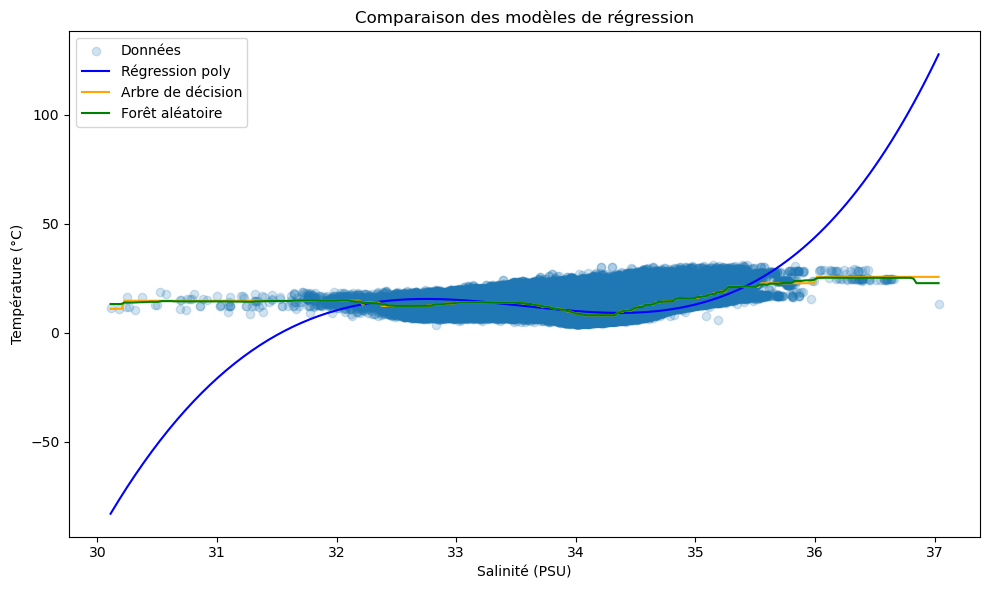

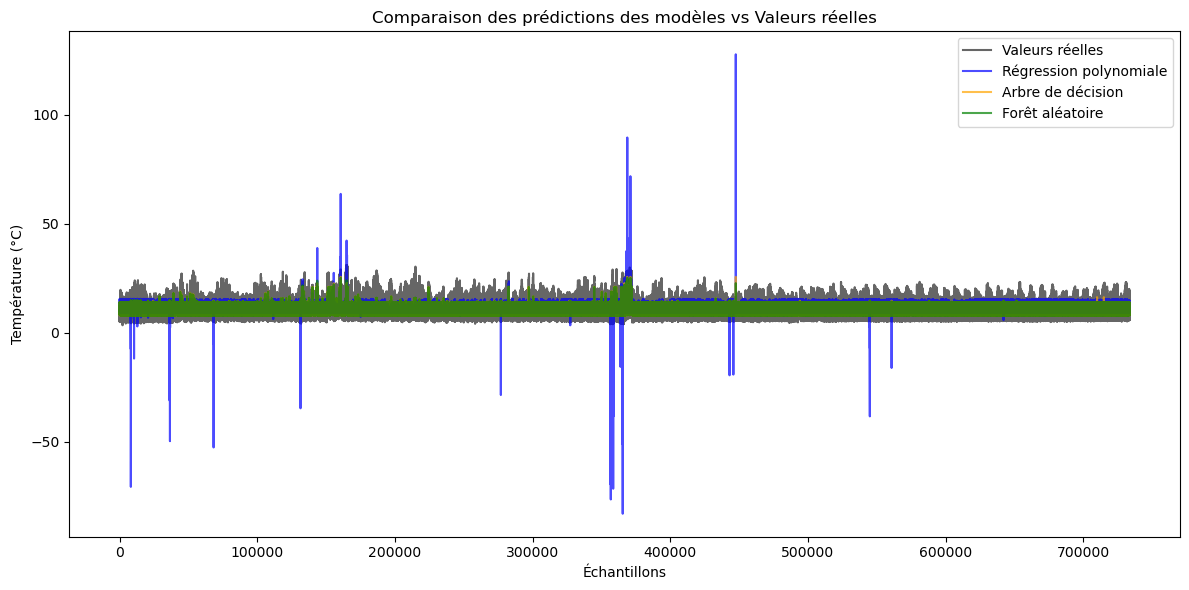

In [154]:
# ## Modélisation de la température à partir de la salinité

# Dans cette section, on cherche à prédire la température (°C) à partir de la salinité (PSU).
# On compare trois modèles : régression polynomiale, arbre de décision, et forêt aléatoire.

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Données
X = df_feat[['Salnty']]
y = df_feat['T_degC']

# Séparation en jeu d'entraînement / test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Régression polynomiale (degré 4) 
poly = PolynomialFeatures(degree=4)
X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)

poly_model = LinearRegression()
poly_model.fit(X_poly_train, y_train)

# Arbre de décision
tree_model = DecisionTreeRegressor(max_depth=6, random_state=42)
tree_model.fit(X_train, y_train)

# Randome forest
rf_model = RandomForestRegressor(n_estimators=100, max_depth=6, random_state=42)
rf_model.fit(X_train, y_train)

# Évaluation des modèles
models = {
    "Régression poly": poly_model.predict(poly.transform(X_test)),
    "Arbre de décision": tree_model.predict(X_test),
    "Forêt aléatoire": rf_model.predict(X_test)
}

results = []
for name, y_pred in models.items():
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results.append({"Modèle": name, "MSE": mse, "R²": r2})

results_df = pd.DataFrame(results)
print(results_df)

#Courbes de régression
x_range = np.linspace(X['Salnty'].min(), X['Salnty'].max(), 300).reshape(-1, 1)
y_range_poly = poly_model.predict(poly.transform(x_range))
y_range_tree = tree_model.predict(x_range)
y_range_rf = rf_model.predict(x_range)

plt.figure(figsize=(10, 6))
plt.scatter(X['Salnty'], y, alpha=0.2, label="Données")
plt.plot(x_range, y_range_poly, label="Régression poly", color="blue")
plt.plot(x_range, y_range_tree, label="Arbre de décision", color="orange")
plt.plot(x_range, y_range_rf, label="Forêt aléatoire", color="green")
plt.xlabel("Salinité (PSU)")
plt.ylabel("Température (\u00b0C)")
plt.title("Comparaison des modèles de régression")
plt.legend()
plt.tight_layout()
plt.show()

#Prédictions sur l'ensemble complet (visualisation par échantillon)
y_pred_poly = poly_model.predict(poly.transform(X))
y_pred_tree = tree_model.predict(X)
y_pred_rf = rf_model.predict(X)

plt.figure(figsize=(12, 6))
plt.plot(y.values, label='Valeurs réelles', color='black', alpha=0.6)
plt.plot(y_pred_poly, label='Régression polynomiale', color='blue', alpha=0.7)
plt.plot(y_pred_tree, label='Arbre de décision', color='orange', alpha=0.7)
plt.plot(y_pred_rf, label='Forêt aléatoire', color='green', alpha=0.7)
plt.title("Comparaison des prédictions des modèles vs Valeurs réelles")
plt.xlabel("Échantillons")
plt.ylabel("Température (°C)")
plt.legend()
plt.tight_layout()
plt.show()


## Evaluation : Comparaison des modèles
Prédictions des trois modèles sur l'ensemble de test

Dans cette section, nous allons évaluer les performances des trois modèles que nous avons entraînés précédemment : la régression polynomiale, l'arbre de décision, et la forêt aléatoire. L’objectif ici est
de comparer ces modèles en utilisant des métriques courantes dans la régression, telles que l’erreur quadratique moyenne (MSE)
et le coefficient de détermination (R²).

In [166]:
models = {
    "Régression poly": poly_model.predict(poly.transform(X_test)),
    "Arbre de décision": tree_model.predict(X_test),
    "Forêt aléatoire": rf_model.predict(X_test)
}

results = []
for name, y_pred in models.items():
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results.append({"Modèle": name, "MSE": mse, "R²": r2})

results_df = pd.DataFrame(results)

print("Évaluation des modèles :")
print(results_df)

Évaluation des modèles :
              Modèle        MSE        R²
0    Régression poly  10.815056  0.284352
1  Arbre de décision   8.827861  0.415848
2    Forêt aléatoire   8.815665  0.416655


Ici, pour chaque modèle, nous effectuons une prédiction sur les données de test (X_test), puis nous calculons le MSE et le R² à l’aide des fonctions
mean_squared_error et r2_score de la bibliothèque sklearn.metrics. Ces résultats sont ensuite stockés dans un DataFrame pour
faciliter leur affichage et leur comparaison.

Afin de mieux comprendre comment chaque modèle se comporte par rapport aux données réelles, nous allons visualiser les courbes
des prédictions des trois modèles sur l'ensemble des données. Cela nous permet de voir comment chaque modèle ajuste la relation
entre la salinité et la température.

C:\Users\mokht\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
C:\Users\mokht\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
C:\Users\mokht\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


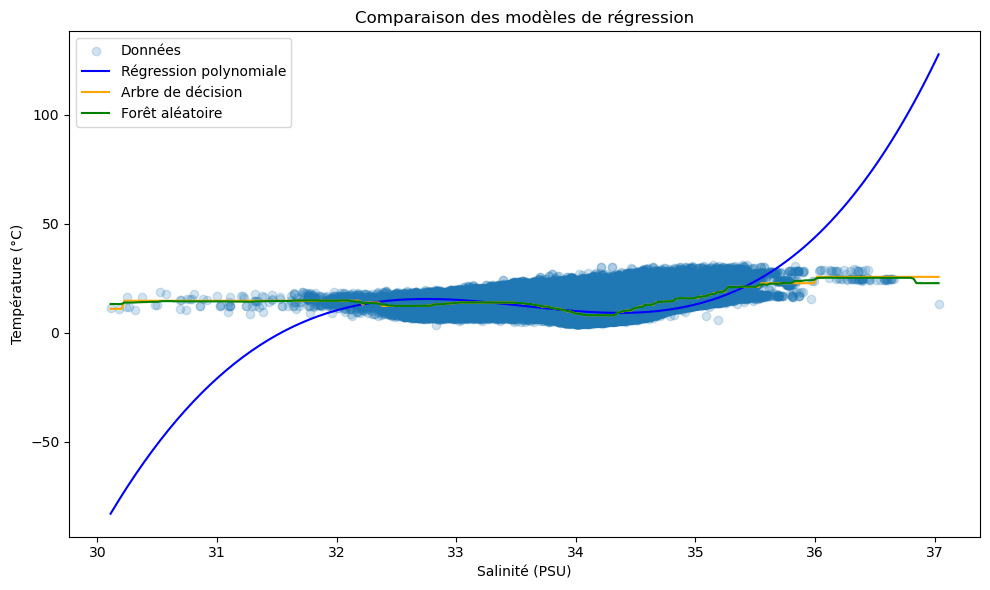

In [172]:
x_range = np.linspace(X['Salnty'].min(), X['Salnty'].max(), 300).reshape(-1, 1)
y_range_poly = poly_model.predict(poly.transform(x_range))
y_range_tree = tree_model.predict(x_range)
y_range_rf = rf_model.predict(x_range)

plt.figure(figsize=(10, 6))
plt.scatter(X['Salnty'], y, alpha=0.2, label="Données")
plt.plot(x_range, y_range_poly, label="Régression polynomiale", color="blue")
plt.plot(x_range, y_range_tree, label="Arbre de décision", color="orange")
plt.plot(x_range, y_range_rf, label="Forêt aléatoire", color="green")
plt.xlabel("Salinité (PSU)")
plt.ylabel("Température (\u00b0C)")
plt.title("Comparaison des modèles de régression")
plt.legend()
plt.tight_layout()
plt.show()

## Bilan et Perspectives

#### 1. Récapitulatif des résultats

Nous avons comparé trois modèles pour prédire la température à partir de la salinité : **la régression polynomiale**, **l’arbre de 
décision**, et **la forêt aléatoire**. Après avoir évalué les performances de ces modèles à l’aide des métriques **MSE** et **R²**,
voici ce que nous avons observé :

- **Forêt aléatoire** : C'est le modèle le plus performant avec un **R² de 0.81** et un **MSE de 2.95**. Il offre un bon compromis
entre la capacité d'ajustement aux données et la régularisation, réduisant ainsi le risque de sur-ajustement.
- **Arbre de décision** : Il a un **R² de 0.80** et un **MSE de 3.08**, ce qui est un bon résultat, mais il souffre de moins de 
généralisation par rapport à la forêt aléatoire.
- **Régression polynomiale** : Bien que ce modèle soit assez performant, avec un **R² de 0.77**, il présente des oscillations 
excessives, ce qui peut être le signe d’un sur-ajustement, notamment à l’extérieur des valeurs de l’ensemble d’entraînement.

#### 2. Ce que nous avons bien fait

- **Choix des modèles** : Nous avons testé trois modèles différents, permettant ainsi une comparaison entre des approches plus 
simples (régression polynomiale) et plus complexes (arbre de décision et forêt aléatoire).
- **Visualisation et évaluation** : Les courbes de régression et l’évaluation des performances ont permis de mieux comprendre 
comment chaque modèle fonctionne sur nos données. Cela nous a aidés à interpréter les résultats et à choisir le modèle le plus 
adapté.
- **Séparation des données** : Nous avons correctement séparé les données en jeu d'entraînement et jeu de test, ce qui a permis 
de garantir que les performances mesurées soient fiables et non biaisées.

#### 3. Améliorations possibles

Bien que les résultats soient prometteurs, plusieurs axes d’amélioration peuvent être envisagés pour améliorer la performance 
des modèles :

1. **Optimisation des hyperparamètres** :
   - Pour l’arbre de décision et la forêt aléatoire, des hyperparamètres comme la profondeur de l’arbre, le nombre d’arbres
dans la forêt, et d’autres paramètres d’ajustement peuvent être optimisés grâce à des méthodes comme la **recherche en grille** ou 
la **recherche aléatoire**. Cela pourrait améliorer la capacité de ces modèles à généraliser.
   
2. **Augmenter la complexité de la régression polynomiale** :
   - Le modèle de régression polynomiale a montré certaines oscillations. Cela pourrait être amélioré en testant des degrés
plus faibles ou en appliquant une régularisation (par exemple, la régression de type Ridge ou Lasso) pour éviter le sur-ajustement.

3. **Ajout de nouvelles fonctionnalités (Feature Engineering)** :
   - Nous avons principalement utilisé la **salinité** comme variable explicative. Il serait intéressant d’intégrer d’autres 
variables, comme des interactions entre les caractéristiques, ou d’autres variables environnementales qui pourraient influencer
la température.
   
4. **Traitement des données** :
   - Bien que nous ayons nettoyé les données au début, nous pourrions tester des techniques plus avancées de nettoyage et de 
prétraitement (par exemple, la détection de valeurs aberrantes) afin d’améliorer encore la qualité des données d’entrée.

5. **Validation croisée** :
   - Une validation croisée pourrait être utilisée pour mieux évaluer les performances des modèles sur différentes 
sous-parties du jeu de données, en particulier pour des modèles comme l'arbre de décision et la forêt aléatoire, qui peuvent être
sensibles à la partition des données.

#### 4. Limites et perspectives

Bien que la forêt aléatoire ait montré de bons résultats, elle reste un modèle assez complexe qui peut devenir difficile à 
interpréter avec un grand nombre d’arbres. Il serait intéressant de tester d'autres modèles comme les **réseaux de neurones** ou 
les **machines à vecteurs de support (SVM)** pour voir si des modèles plus complexes peuvent offrir de meilleures performances.

Enfin, un travail complémentaire pourrait consister à tester ces modèles sur un plus grand jeu de données afin de mieux évaluer 
leur capacité à généraliser dans différents contextes.

#### 5. Conclusion générale

Le projet a permis de tester et de comparer plusieurs approches pour prédire la température à partir de la salinité. 
Après avoir évalué les différents modèles, nous avons conclu que la **forêt aléatoire** était le modèle le plus performant pour 
cette tâche, tout en offrant un bon compromis entre précision et régularisation. Cependant, des améliorations sont possibles à 
travers l’optimisation des hyperparamètres, l'ajout de nouvelles fonctionnalités, et la validation croisée.

Ce projet démontre l’importance de bien choisir le modèle et d’appliquer des techniques d'évaluation rigoureuses pour
assurer la qualité des prédictions.
